In [1]:
using LinearAlgebra, SparseArrays, Parameters, LinearMaps, Plots

In [2]:
# #1D Matrix operator utility functions.
# spI(n) = spdiagm(n,n, 0 => ones(n))
# ∂1d(n,dx) = spdiagm(n,n+1,0 => -ones(n), 1 => ones(n))/dx
# c(n) = spdiagm(n,n+1,0 => ones(n), 1 => ones(n))/2
# χ(n) = spdiagm(n,n+2, 1 => ones(n))


In [3]:
# A = spI(5)
# rank(∂1d(5,0.1))
# ∂1d(5,0.1)

In [45]:
using LinearAlgebra, Serialization

# Define parameters
Base.@kwdef struct Params
    y_BC::String = "Neumann" # or "traction_free"
    k::Float64 = 1e-8       # small numerical factor
    λ::Float64 = 1.0
    μ::Float64 = 1.0
    Lx::Float64 = 1.0
    Nx::Int = 15
    Δx::Float64 = Lx/(Nx-1) # spatial step
    Ly::Float64 = 1.0
    Ny::Int = 16
    Δy::Float64 = Ly/(Ny-1) # spatial step
    T::Int = 10 + 1         # number of steps for pseudotime
    dt::Float64 = 1/(T-1)   # step in pseudotime
    tol::Float64 = 1e-6     # convergence tolerance
    max_iter::Int = 20      # max staggered iterations
    savefile::String = "sol.jls" # file to save iterations
end

# ------------------------------------------------------------
# Grid indexing (column major)
# ------------------------------------------------------------
lin(i,j,Nx) = i + (j-1)*Nx

# ------------------------------------------------------------
# Derivatives (1st order boundary, 2nd interior)
# ------------------------------------------------------------
function Dx(f,i,j,p::Params)
    Nx = p.Nx
    Δx = p.Δx
    if i == 1
        return (f[i+1,j] - f[i,j]) / Δx
    elseif i == Nx
        return (f[i,j] - f[i-1,j]) / Δx
    else
        return (f[i+1,j] - f[i-1,j]) / (2Δx)
    end
end

function Dy(f,i,j,p::Params)
    Ny = p.Ny
    Δy = p.Δy
    if j == 1
        return (f[i,j+1] - f[i,j]) / Δy
    elseif j == Ny
        return (f[i,j] - f[i,j-1]) / Δy
    else
        return (f[i,j+1] - f[i,j-1]) / (2Δy)
    end
end

# degradation function
function g(d,i,j,p::Params)
    return (1.0-d[i,j])^2 + p.k
end

# Build Q,P coefficients after linearization
function build_QP(d,a1_bar,a2_bar,p::Params)

    Nx = p.Nx
    Ny = p.Ny

    Q11 = zeros(Nx,Ny)
    P11 = zeros(Nx,Ny)
    Q12 = zeros(Nx,Ny)
    P12 = zeros(Nx,Ny)

    Q21 = zeros(Nx,Ny)
    P21 = zeros(Nx,Ny)
    Q22 = zeros(Nx,Ny)
    P22 = zeros(Nx,Ny)

    for j in 1:Ny
        for i in 1:Nx

            a1barx  = Dx(a1_bar,i,j,p)
            a1bary  = Dy(a1_bar,i,j,p)
            a2barx  = Dx(a2_bar,i,j,p)
            a2bary  = Dy(a2_bar,i,j,p)

            λ,μ = p.λ,p.μ

            # pressure
            pres = -(λ + 2μ/3)*(a1barx + a2bary)
            # mask
            if pres <= 0 
                m_p = 1.0
            else    
                m_p = g(d, i, j, p)
            end

            # from linearisation
            fbar = sqrt((a1barx - a2bary)^2 + (a1bary + a2barx)^2)

            if fbar == 0.0 # strictly
                r1x = 1/6 - 1/(2^(3/2))
                r1y = -1/(2^(3/2))
                r2x = -1/(2^(3/2))
                r2y = 1/6 + 1/(2^(3/2))
            else
                r1x = 1/6 - (a1barx - a2bary)/(2fbar)
                r1y = -(a1bary + a2barx)/(2fbar)
                r2x = -(a1bary + a2barx)/(2fbar)
                r2y = 1/6 + (a1barx - a2bary)/(2fbar)
            end

            q1 = (a1barx + a2bary)/6 - 0.5*fbar
            q2 = (a1barx + a2bary)/6 + 0.5*fbar
            # masks
            m_q1 = q1 <= 0 ? 1.0 : g(d, i, j, p)
            m_q2 = q2 <= 0 ? 1.0 : g(d, i, j, p)

            # coefficients
            Q11[i,j] = m_p*(λ + 2μ/3) + m_q1*r1x
            P11[i,j] = 2*m_q1*r1y
            Q12[i,j] = 2*m_q1*r2x
            P12[i,j] = m_p*(λ + 2μ/3) + m_q1*r2y

            Q21[i,j] = m_p*(λ + 2μ/3) + m_q2*r2y
            P21[i,j] = -2*m_q2*r1y
            Q22[i,j] = -2*m_q2*r2x
            P22[i,j] = m_p*(λ + 2μ/3) + m_q2*r1x
        end
    end

    return Q11,P11,Q12,P12,Q21,P21,Q22,P22
end

# Build global matrix M and rhs b
function build_system(Q11,P11,Q12,P12,
                      Q21,P21,Q22,P22,
                      p::Params,
                      a1_left, a2_left,
                      a1_right, a2_right)

    Nx,Ny = p.Nx,p.Ny
    Δx,Δy = p.Δx,p.Δy
    Ntot = Nx*Ny # a1, a2 are vectorized
    Ndof = 2*Ntot # for both a1 and a2

    M = zeros(Ndof,Ndof)
    b = zeros(Ndof)

    # Dirichlet in x
    # for i = 1
    for j in 1:Ny
        k = lin(1,j,Nx)
        k1 = k # for a1 positions in vector [a1, a2]
        k2 = k + Ntot # for a2...
        M[k1,k1]=1; b[k1]=a1_left[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_left[j]
    end
    # for i = Nx
    for j in 1:Ny
        k = lin(Nx,j,Nx)
        k1 = k # for a1
        k2 = k + Ntot # for a2
        M[k1,k1]=1; b[k1]=a1_right[j] # grid function of y
        M[k2,k2]=1; b[k2]=a2_right[j]
    end
    
    # BC in y
    if p.y_BC=="Neumann" # using 1st order stencils
        # for j=1
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,1,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = -1/Δy
            M[k1,lin(i,2,Nx)] = 1/Δy
            M[k2,k2] = -1/Δy
            M[k2,lin(i,2,Nx)+Ntot] = 1/Δy
        end
        # for j=Ny
        for i in 2:Nx-1 # the edges of x are given by the Dirichlet BCs in x
            k = lin(i,Ny,Nx)
            k1 = k # for a1 positions in vector [a1, a2]
            k2 = k + Ntot # for a2...
            M[k1,k1] = 1/Δy
            M[k1,lin(i,Ny-1,Nx)] = -1/Δy
            M[k2,k2] = 1/Δy
            M[k2,lin(i,Ny-1,Nx)+Ntot] = -1/Δy
        end
    elseif p.y_BC=="traction_free"
        #TODO
    end
    
    for j in 2:Ny-1
        for i in 2:Nx-1

            # midpoints in x
            P11_i_mhalf_j = 0.5*(P11[i-1,j]+P11[i,j])
            P11_i_phalf_j = 0.5*(P11[i,j]+P11[i+1,j])
            Q11_i_mhalf_j = 0.5*(Q11[i-1,j]+Q11[i,j])
            Q11_i_phalf_j = 0.5*(Q11[i,j]+Q11[i+1,j])
            P12_i_mhalf_j = 0.5*(P12[i-1,j]+P12[i,j])
            P12_i_phalf_j = 0.5*(P12[i,j]+P12[i+1,j])
            Q12_i_mhalf_j = 0.5*(Q12[i-1,j]+Q12[i,j])
            Q12_i_phalf_j = 0.5*(Q12[i,j]+Q12[i+1,j])
            # midpoints in y
            P21_i_j_mhalf = 0.5*(P21[i,j-1]+P21[i,j])
            P21_i_j_phalf = 0.5*(P21[i,j]+P21[i,j+1])
            Q21_i_j_mhalf = 0.5*(Q21[i,j-1]+Q21[i,j])
            Q21_i_j_phalf = 0.5*(Q21[i,j]+Q21[i,j+1])
            P22_i_j_mhalf = 0.5*(P22[i,j-1]+P22[i,j])
            P22_i_j_phalf = 0.5*(P22[i,j]+P22[i,j+1])
            Q22_i_j_mhalf = 0.5*(Q22[i,j-1]+Q22[i,j])
            Q22_i_j_phalf = 0.5*(Q22[i,j]+Q22[i,j+1])

            k = lin(i,j,Nx)
            k1 = k # for a1
            k2 = k + Ntot # for a2

            # 1st eq; rhs = 0
            # for a1 part
            M[k1,lin(i-1,j-1,Nx)] = 0.25*P11_i_mhalf_j/Δy
            M[k1,lin(i-1,j,Nx)] = Q11_i_mhalf_j/Δx
            M[k1,lin(i-1,j+1,Nx)] = -0.25*P11_i_mhalf_j/Δy
            M[k1,lin(i,j-1,Nx)] = 0.25*(P11_i_mhalf_j-P11_i_phalf_j)/Δy
            M[k1,k1] = -(Q11_i_mhalf_j+Q11_i_phalf_j)/Δx
            M[k1,lin(i,j+1,Nx)] = 0.25*(P11_i_phalf_j-P11_i_mhalf_j)/Δy
            M[k1,lin(i+1,j-1,Nx)] = -0.25*P11_i_phalf_j/Δy
            M[k1,lin(i+1,j,Nx)] = Q11_i_phalf_j/Δx
            M[k1,lin(i+1,j+1,Nx)] = 0.25*P11_i_phalf_j/Δy
            # for a2 part
            M[k1,lin(i-1,j-1,Nx)+Ntot] = 0.25*P12_i_mhalf_j/Δy
            M[k1,lin(i-1,j,Nx)+Ntot] = Q12_i_mhalf_j/Δx
            M[k1,lin(i-1,j+1,Nx)+Ntot] = -0.25*P12_i_mhalf_j/Δy
            M[k1,lin(i,j-1,Nx)+Ntot] = 0.25*(P12_i_mhalf_j-P12_i_phalf_j)/Δy
            M[k1,k2] = -(Q12_i_mhalf_j+Q12_i_phalf_j)/Δx
            M[k1,lin(i,j+1,Nx)+Ntot] = 0.25*(P12_i_phalf_j-P12_i_mhalf_j)/Δy
            M[k1,lin(i+1,j-1,Nx)+Ntot] = -0.25*P12_i_phalf_j/Δy
            M[k1,lin(i+1,j,Nx)+Ntot] = Q12_i_phalf_j/Δx
            M[k1,lin(i+1,j+1,Nx)+Ntot] = 0.25*P12_i_phalf_j/Δy

            # 2nd eq; rhs = 0
            # for a1 part
            M[k2,lin(i-1,j-1,Nx)] = 0.25*Q21_i_j_mhalf/Δx
            M[k2,lin(i-1,j,Nx)] = 0.25*(Q21_i_j_mhalf-Q21_i_j_phalf)/Δx
            M[k2,lin(i-1,j+1,Nx)] = -0.25*Q21_i_j_phalf/Δx
            M[k2,lin(i,j-1,Nx)] = P21_i_j_mhalf/Δy
            M[k2,k1] = -(P21_i_j_mhalf+P21_i_j_phalf)/Δy
            M[k2,lin(i,j+1,Nx)] = P21_i_j_phalf/Δy
            M[k2,lin(i+1,j-1,Nx)] = -0.25*Q21_i_j_mhalf/Δx
            M[k2,lin(i+1,j,Nx)] = 0.25*(Q21_i_j_phalf-Q21_i_j_mhalf)/Δx
            M[k2,lin(i+1,j+1,Nx)] = 0.25*Q21_i_j_phalf/Δx
            # for a2 part
            M[k2,lin(i-1,j-1,Nx)+Ntot] = 0.25*Q22_i_j_mhalf/Δx
            M[k2,lin(i-1,j,Nx)+Ntot] = 0.25*(Q22_i_j_mhalf-Q22_i_j_phalf)/Δx
            M[k2,lin(i-1,j+1,Nx)+Ntot] = -0.25*Q22_i_j_phalf/Δx
            M[k2,lin(i,j-1,Nx)+Ntot] = P22_i_j_mhalf/Δy
            M[k2,k2] = -(P22_i_j_mhalf+P22_i_j_phalf)/Δy
            M[k2,lin(i,j+1,Nx)+Ntot] = P22_i_j_phalf/Δy
            M[k2,lin(i+1,j-1,Nx)+Ntot] = -0.25*Q22_i_j_mhalf/Δx
            M[k2,lin(i+1,j,Nx)+Ntot] = 0.25*(Q22_i_j_phalf-Q22_i_j_mhalf)/Δx
            M[k2,lin(i+1,j+1,Nx)+Ntot] = 0.25*Q22_i_j_phalf/Δx

        end
    end

    return M,b
end

build_system (generic function with 1 method)

In [71]:
p = Params(
    λ = 0.2,
    μ = 0.4,
    Nx = 10,
    Ny = 10,
    max_iter = 1
)

Params("Neumann", 1.0e-8, 0.2, 0.4, 1.0, 10, 0.1111111111111111, 1.0, 10, 0.1111111111111111, 11, 0.1, 1.0e-6, 1, "sol.jls")

In [73]:
a1 = zeros(p.Nx, p.Ny)
a2 = zeros(p.Nx, p.Ny)

a1_bar = copy(a1)
a2_bar = copy(a2)
d = copy(a2)

10×10 Matrix{Float64}:
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0
 0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0

In [90]:
x = range(0,p.Lx,p.Nx)
y = range(0,p.Ly,p.Ny)
for j in 1:p.Ny
    for i in 1:p.Nx
        a1_bar[i,j] = 1e-4*sin(x[i])*cos(y[j])
        a2_bar[i,j] = 2*1e-3*cos(x[i])*sin(2*y[j])
    end
end

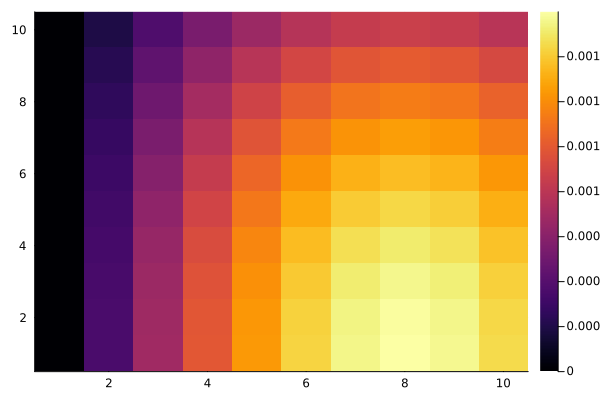

In [91]:
heatmap(a2_bar)

In [92]:
Q11,P11,Q12,P12,Q21,P21,Q22,P22 =
    build_QP(d,a1_bar,a2_bar,p)

([1.1333333333333333 1.1333228093417174 … 0.13711522882302957 0.13482804087293027; 1.133333326924622 1.1332888224832383 … 0.14918768776465025 0.1398000249661619; … ; 1.1333325521564956 1.1279938027084084 … 0.46771237070808197 0.38979924264807875; 1.1333320789871644 1.125408435671047 … 0.4943707656740969 0.4250019119225569], [-0.0 0.006488106306629184 … 0.1227613640333516 0.07726496583192066; 0.0001601088547050219 0.01334299349908596 … 0.24982385280985797 0.16031056017422643; … ; 0.0017676834868943791 0.1457534910405985 … 0.9435458551512786 0.8733639433847068; 0.002239950531312166 0.17733689587142842 … 0.960602734729749 0.9090610912552333], [-0.0 0.006488106306629184 … 0.1227613640333516 0.07726496583192066; 0.0001601088547050219 0.01334299349908596 … 0.24982385280985797 0.16031056017422643; … ; 0.0017676834868943791 0.1457534910405985 … 0.9435458551512786 0.8733639433847068; 0.002239950531312166 0.17733689587142842 … 0.960602734729749 0.9090610912552333], [0.1333333333333333 0.13334385

In [93]:
a1_left  = 0.0*ones(p.Ny)
a1_right = 1e-4*ones(p.Ny)
a2_left  = 0.0*ones(p.Ny)
a2_right = 2*1e-4*ones(p.Ny)

10-element Vector{Float64}:
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002
 0.0002

In [94]:
M,b = build_system(
    Q11,P11,Q12,P12,
    Q21,P21,Q22,P22,
    p,
    a1_left,a1_right,
    a2_left,a2_right)

([1.0 0.0 … 0.0 0.0; 0.0 -9.0 … 0.0 0.0; … ; 0.0 0.0 … 9.0 0.0; 0.0 0.0 … 0.0 1.0], [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0  …  0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002])

In [95]:
println("rank(M) = ", rank(M))
println("size(M) = ", size(M))
# println("det(M) = ", det(M))
# println("cond(M) = ", cond(M))

rank(M) = 200
size(M) = (200, 200)


In [96]:
M

200×200 Matrix{Float64}:
 1.0       0.0         0.0        …  0.0  0.0  0.0      0.0      0.0
 0.0      -9.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0        -9.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0        …  0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0           0.0  0.0  0.0      0.0      0.0
 0.0       0.0         0.0        …  0.0  0.0  0.0      0.0      0.0
 0.02231  -0.0230926  -0.0454026     0.0  0.0  0.0      0.0      0.0
 0.0       0.0454026  -0.0315388     0.0  0.0  0.0      0.0      0.0
 ⋮                                ⋱  ⋮                          
 0.0       0.

In [97]:
sol = M \ b

200-element Vector{Float64}:
 0.0
 4.1124240135895885e-7
 1.970958645178876e-6
 1.1350691416523292e-6
 3.5744966643477875e-6
 1.2940367343633823e-6
 4.881263437996218e-6
 9.806734492826055e-7
 6.534643944301249e-6
 0.0
 5.387137624453322e-20
 4.1124240135895885e-7
 1.970958645178876e-6
 ⋮
 0.00017609516690391932
 0.00020000000000000006
 0.0001
 0.00014337298181180624
 0.00012826382138446813
 0.0001563612525562033
 0.00014938754979990275
 0.00017672637134068307
 0.0001661229756524151
 0.00019178112165217913
 0.00017609516690391932
 0.0002

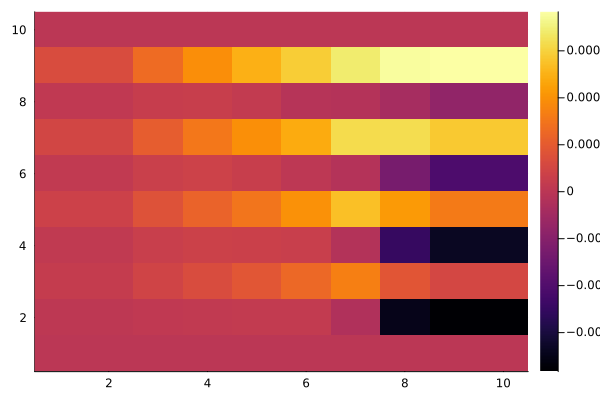

In [98]:
Ntot = p.Nx*p.Ny
a1sol = reshape(sol[1:Ntot], p.Nx, p.Ny)
heatmap(a1sol)

In [99]:
a1sol

10×10 Matrix{Float64}:
 0.0         5.38714e-20  2.25881e-19  …  -1.30884e-19  -1.45003e-18
 4.11242e-7  4.11242e-7   1.00778e-6      -3.83047e-5   -3.83047e-5
 1.97096e-6  1.97096e-6   4.4033e-6        5.3173e-6     5.3173e-6
 1.13507e-6  1.13507e-6   2.71663e-6      -3.38018e-5   -3.38018e-5
 3.5745e-6   3.5745e-6    7.84441e-6       1.59795e-5    1.59795e-5
 1.29404e-6  1.29404e-6   3.05468e-6   …  -2.09401e-5   -2.09401e-5
 4.88126e-6  4.88126e-6   1.04e-5          2.86121e-5    2.86121e-5
 9.80673e-7  9.80673e-7   2.25453e-6      -8.1422e-6    -8.1422e-6
 6.53464e-6  6.53464e-6   1.32162e-5       3.83107e-5    3.83107e-5
 0.0         3.55243e-19  5.33387e-21     -8.83146e-20   0.0

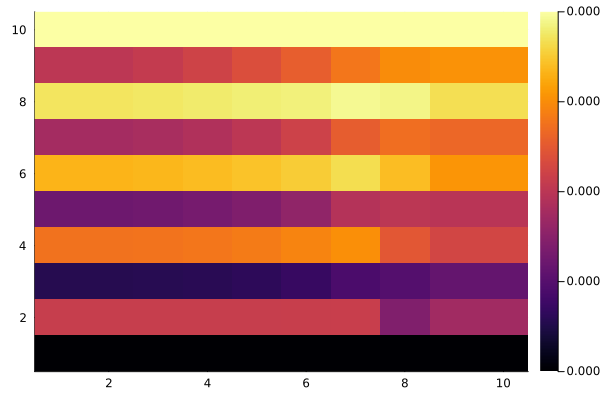

In [100]:
a2sol = reshape(sol[Ntot+1:2*Ntot], p.Nx, p.Ny)
heatmap(a2sol)

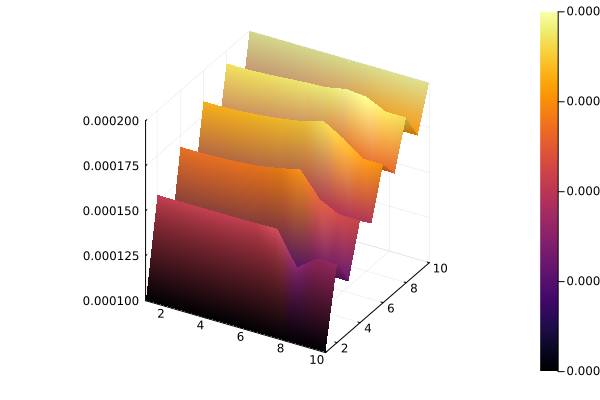

In [101]:
surface(a2sol)

In [102]:
norm(M - M') 

272.450692191514